# 05 - Motor restringido de recomendaciones

## 1. Dependencias

In [1]:
#Instalar dependencias
%pip install pandas numpy scikit-learn matplotlib joblib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Configuración

In [2]:
#Librerías
import platform
import sys
from pathlib import Path
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [3]:
#Configuración
SEMILLA = 20260727
UMBRAL_ESTADO = 0.50
UMBRAL_RECOMENDACION = 0.50
COBERTURA_ESENCIAL_MINIMA_MESES = 1.0
VERSION_MODELO = 'fincoach_recomendaciones_mvp_v3'

ruta_decisiones = Path('../Datasets/decisiones_recomendaciones.csv')
ruta_trayectorias = Path('../Datasets/trayectorias_financieras.csv')
ruta_perfiles = Path('../Datasets/perfil_integral_usuario.csv')
ruta_estados_ventana = Path('../Resultados/04_estados_por_ventana.csv')
ruta_estados_actuales = Path('../Resultados/04_estados_trayectoria.csv')
ruta_modelo_estados = Path('../Modelos/04_estados_trayectoria.joblib')
ruta_modelo = Path('../Modelos/05_motor_recomendaciones.joblib')
ruta_resultados = Path('../Resultados')
ruta_graficas = ruta_resultados / 'Graficas'

versiones = pd.DataFrame([
    {'componente': 'python', 'version': sys.version.split()[0]},
    {'componente': 'pandas', 'version': pd.__version__},
    {'componente': 'numpy', 'version': np.__version__},
    {'componente': 'scikit-learn', 'version': sklearn.__version__},
    {'componente': 'matplotlib', 'version': matplotlib.__version__},
    {'componente': 'sistema', 'version': platform.platform()},
])

display(versiones)

,componente,version
0,python,3.14.3
1,pandas,3.0.3
2,numpy,2.5.1
3,scikit-learn,1.9.0
4,matplotlib,3.11.1
5,sistema,macOS-26.5.2-arm64-arm-64bit-Mach-O


## 3. Carga de productos anteriores

In [4]:
#Cargar datos
rutas_requeridas = [
    ruta_decisiones,
    ruta_trayectorias,
    ruta_perfiles,
    ruta_estados_ventana,
    ruta_estados_actuales,
    ruta_modelo_estados,
]

for ruta in rutas_requeridas:
    assert ruta.exists(), f'No existe {ruta}'

decisiones = pd.read_csv(ruta_decisiones, low_memory=False)
trayectorias = pd.read_csv(ruta_trayectorias, low_memory=False)
perfiles = pd.read_csv(ruta_perfiles, low_memory=False)
estados_ventana = pd.read_csv(ruta_estados_ventana, low_memory=False)
estados_actuales = pd.read_csv(ruta_estados_actuales, low_memory=False)
artefacto_estados = joblib.load(ruta_modelo_estados)
assert artefacto_estados['version_modelo'] == 'fincoach_estados_trayectoria_mvp_v3', 'Ejecuta nuevamente el notebook 04'

for columna in ['fecha_decision']:
    decisiones[columna] = pd.to_datetime(decisiones[columna], errors='coerce')

for columna in ['fecha_corte', 'periodo_desde', 'periodo_hasta']:
    trayectorias[columna] = pd.to_datetime(trayectorias[columna], errors='coerce')
    if columna in estados_ventana.columns:
        estados_ventana[columna] = pd.to_datetime(estados_ventana[columna], errors='coerce')
    if columna in estados_actuales.columns:
        estados_actuales[columna] = pd.to_datetime(estados_actuales[columna], errors='coerce')

resumen_fuentes = pd.DataFrame([
    {'fuente': 'decisiones', 'filas': len(decisiones), 'perfiles': decisiones['perfil_id'].nunique()},
    {'fuente': 'trayectorias', 'filas': len(trayectorias), 'perfiles': trayectorias['perfil_id'].nunique()},
    {'fuente': 'estados por ventana', 'filas': len(estados_ventana), 'perfiles': estados_ventana['perfil_id'].nunique()},
    {'fuente': 'estados actuales', 'filas': len(estados_actuales), 'perfiles': estados_actuales['perfil_id'].nunique()},
])

display(resumen_fuentes)
display(decisiones.head(5))


,fuente,filas,perfiles
0,decisiones,600,200
1,trayectorias,600,200
2,estados por ventana,600,200
3,estados actuales,200,200


,decision_id,perfil_id,estado_alcance_mvp,ventana_id,fecha_decision,estado_trayectoria,recomendacion_id,recomendacion,tipo_recomendacion,meta_relacionada,...,razon_decision,evidencia_utilizada,riesgo_si_se_aplica,revision_humana,particion,historia_financiera_controlada,es_sintetico,version_catalogo,version_esquema,huella_registro
0,DEC_0001_04,PERF_0001,dentro_del_mvp,VEN_0001_1,2026-04-30,situacion_critica,REC_BUSCAR_APOYO_Y_CONTENER,Los pagos y gastos superan claramente los recu...,contencion_y_revision,crear_fondo_emergencia,...,"Entre 2026-04-01 y 2026-04-30, el balance fue ...",VEN_0001_1 | movimientos_confirmados | indicad...,Aumentar la deuda o quedarse sin recursos para...,requerida,train,acumulacion_estable,si,recomendaciones_amigables_mvp_v2.0,fincoach_mvp_estructurado_v2.0,c3bf655ef7b1af64e2df35d4ec8b87c426b019353ce146...
1,DEC_0001_05,PERF_0001,dentro_del_mvp,VEN_0001_2,2026-05-31,fragilidad_sostenida,REC_PROTEGER_ESENCIALES_Y_DEUDA,En este momento el dinero no alcanza con holgu...,proteccion_esencial,crear_fondo_emergencia,...,"Entre 2026-04-01 y 2026-05-31, el balance fue ...",VEN_0001_2 | movimientos_confirmados | indicad...,Dejar sin cobertura una necesidad básica o inc...,recomendada,train,acumulacion_estable,si,recomendaciones_amigables_mvp_v2.0,fincoach_mvp_estructurado_v2.0,6204a5795f8f2461c9189850f73e54416e8a93888cd4a4...
2,DEC_0001_06,PERF_0001,dentro_del_mvp,VEN_0001_3,2026-06-30,variable_resiliente,REC_GUARDAR_EN_MESES_ALTOS,Tus ingresos cambian de un mes a otro y hasta ...,gestion_ingreso_variable,crear_fondo_emergencia,...,"Entre 2026-04-01 y 2026-06-30, el balance fue ...",VEN_0001_3 | movimientos_confirmados | indicad...,Usar todo el ingreso de un mes alto y quedar s...,no_requerida,train,acumulacion_estable,si,recomendaciones_amigables_mvp_v2.0,fincoach_mvp_estructurado_v2.0,9ecfc358875e340edb4e9909079a5084058dcedfe73568...
3,DEC_0002_04,PERF_0002,dentro_del_mvp,VEN_0002_1,2026-04-30,uso_planificado_reserva,REC_MEDIR_USO_DE_RESERVA,Estás usando parte de tu dinero disponible par...,seguimiento_reserva,ampliar_actividad_economica,...,"Entre 2026-04-01 y 2026-04-30, el balance fue ...",VEN_0002_1 | movimientos_confirmados | indicad...,Consumir la reserva más rápido de lo previsto.,no_requerida,train,equilibrio_sostenible,si,recomendaciones_amigables_mvp_v2.0,fincoach_mvp_estructurado_v2.0,234eec0c11ba9662190c61827ef18e0a8cc59eb430608d...
4,DEC_0002_05,PERF_0002,dentro_del_mvp,VEN_0002_2,2026-05-31,uso_planificado_reserva,REC_MEDIR_USO_DE_RESERVA,Estás usando parte de tu dinero disponible par...,seguimiento_reserva,ampliar_actividad_economica,...,"Entre 2026-04-01 y 2026-05-31, el balance fue ...",VEN_0002_2 | movimientos_confirmados | indicad...,Consumir la reserva más rápido de lo previsto.,no_requerida,train,equilibrio_sostenible,si,recomendaciones_amigables_mvp_v2.0,fincoach_mvp_estructurado_v2.0,9ba4e48b5edfd4f19dc2d8a90d90f7717a194ef55305de...


## 4. Contrato y trazabilidad

In [5]:
#Validar contrato
columnas_decision = [
    'decision_id',
    'perfil_id',
    'ventana_id',
    'estado_trayectoria',
    'recomendacion_id',
    'recomendacion',
    'tipo_recomendacion',
    'meta_relacionada',
    'aspectos_protegidos',
    'condiciones_observadas',
    'decision',
    'prioridad',
    'requiere_confirmacion',
    'condiciones_exclusion',
    'riesgo_si_se_aplica',
    'razon_decision',
    'evidencia_utilizada',
    'revision_humana',
    'particion',
]

columnas_patrones_actuales = [
    'recurrencias_observadas',
    'recurrencias_fijas_observadas',
    'recurrencias_variables_observadas',
    'recurrencias_estacionales_observadas',
]

columnas_faltantes = sorted(set(columnas_decision) - set(decisiones.columns))
columnas_patrones_faltantes = sorted(set(columnas_patrones_actuales) - set(estados_actuales.columns))
texto_recomendaciones = ' '.join(decisiones['recomendacion'].fillna('').astype(str).str.lower())
perfiles_por_particion = decisiones.groupby('perfil_id')['particion'].nunique()
estados_por_ventana = estados_ventana['ventana_id'].value_counts()
errores_contrato = pd.DataFrame([
    {'control': 'columnas requeridas', 'errores': len(columnas_faltantes)},
    {'control': 'patrones actuales separados', 'errores': len(columnas_patrones_faltantes)},
    {'control': 'decisiones duplicadas', 'errores': int(decisiones['decision_id'].duplicated().sum())},
    {'control': 'ventanas duplicadas en estados', 'errores': int(estados_por_ventana.ne(1).sum())},
    {'control': 'perfil en una sola partición', 'errores': int(perfiles_por_particion.gt(1).sum())},
    {'control': 'particiones válidas', 'errores': int((~decisiones['particion'].isin(['train', 'validation', 'test'])).sum())},
    {'control': 'fecha de decisión válida', 'errores': int(decisiones['fecha_decision'].isna().sum())},
    {'control': 'ventanas disponibles en trayectoria', 'errores': int((~decisiones['ventana_id'].isin(trayectorias['ventana_id'])).sum())},
    {'control': 'perfiles disponibles', 'errores': int((~decisiones['perfil_id'].isin(perfiles['perfil_id'])).sum())},
    {'control': 'catálogo versionado', 'errores': int(decisiones['version_catalogo'].nunique() != 1)},
    {'control': 'recomendaciones completas', 'errores': int(decisiones['recomendacion'].fillna('').astype(str).str.strip().eq('').sum())},
    {'control': 'texto anterior eliminado', 'errores': int('mantener el patrón actual' in texto_recomendaciones)},
])

display(errores_contrato)
assert not columnas_faltantes, f'Faltan columnas: {columnas_faltantes}'
assert not columnas_patrones_faltantes, f'Faltan patrones actuales: {columnas_patrones_faltantes}'
assert errores_contrato['errores'].eq(0).all(), 'El contrato de recomendaciones contiene errores'

,control,errores
0,columnas requeridas,0
1,patrones actuales separados,0
2,decisiones duplicadas,0
3,ventanas duplicadas en estados,0
4,perfil en una sola partición,0
5,particiones válidas,0
6,fecha de decisión válida,0
7,ventanas disponibles en trayectoria,0
8,perfiles disponibles,0
9,catálogo versionado,0


In [6]:
#Unir estados y decisiones
columnas_estado = [
    'ventana_id',
    'perfil_id',
    'estado_modelo',
    'estado_reto',
    'estado_calculo_modelo',
    'confianza_pct',
    'nivel_incertidumbre_modelo',
    'estado_ingreso_actual',
    'objetivo_declarado',
    'calidad_datos',
    'factores_positivos',
    'factores_atencion',
    'informacion_faltante',
    'explicacion_periodo',
    'particion',
]
columnas_probabilidad = sorted([
    columna
    for columna in estados_ventana.columns
    if columna.startswith('prob_') and columna.endswith('_pct')
])

datos = decisiones.merge(
    estados_ventana[columnas_estado + columnas_probabilidad],
    on=['ventana_id', 'perfil_id', 'particion'],
    how='left',
    validate='one_to_one',
)
columnas_trayectoria_motor = [
    'ventana_id',
    'perfil_id',
    'periodo_desde',
    'periodo_hasta',
    'actividad_A',
    'balance_operativo_B',
    'liquidez_final',
    'deuda_final',
    'pagos_deuda',
    'periodos_sin_ingreso',
    'variabilidad_ingresos_V',
    'cobertura_esencial_L_meses',
]
columnas_perfil_motor = [
    'perfil_id',
    'objetivo_proximo',
    'meta_declarada',
    'hobby_1',
    'hobby_2',
    'responsabilidad_declarada',
    'tipos_deuda',
]
datos = datos.merge(
    trayectorias[columnas_trayectoria_motor],
    on=['ventana_id', 'perfil_id'],
    how='left',
    validate='one_to_one',
).merge(
    perfiles[columnas_perfil_motor],
    on='perfil_id',
    how='left',
    validate='many_to_one',
)
datos['balance_relativo'] = datos['balance_operativo_B'] / datos['actividad_A'].where(datos['actividad_A'].gt(0))
datos['deuda_relativa'] = datos['deuda_final'] / datos['actividad_A'].where(datos['actividad_A'].gt(0))
datos['pago_deuda_relativo'] = datos['pagos_deuda'] / datos['actividad_A'].where(datos['actividad_A'].gt(0))
datos['tiene_deuda'] = datos['deuda_final'].gt(0).map({True: 'si', False: 'no'})
datos['objetivo_contexto'] = datos['objetivo_proximo'].astype('string').fillna('no declarado')

errores_union = pd.DataFrame([
    {'control': 'estado del notebook 04 disponible', 'errores': int(datos['estado_modelo'].isna().sum())},
    {'control': 'siete porcentajes disponibles', 'errores': abs(len(columnas_probabilidad) - 7)},
    {'control': 'partición conservada', 'errores': int(datos['particion'].isna().sum())},
    {'control': 'trayectoria disponible', 'errores': int(datos['actividad_A'].isna().sum())},
    {'control': 'contexto financiero disponible', 'errores': int(datos['estado_ingreso_actual'].isna().sum())},
])

display(errores_union)
assert errores_union['errores'].eq(0).all(), 'La unión con los estados del notebook 04 falló'

,control,errores
0,estado del notebook 04 disponible,0
1,siete porcentajes disponibles,0
2,partición conservada,0
3,trayectoria disponible,0
4,contexto financiero disponible,0


## 5. Alcance real del catálogo

In [7]:
#Auditar catálogo
recomendaciones_por_estado = datos.groupby('estado_trayectoria')['recomendacion_id'].nunique()
estados_por_recomendacion = datos.groupby('recomendacion_id')['estado_trayectoria'].nunique()
cobertura_recomendaciones = pd.crosstab(
    datos['recomendacion_id'],
    datos['particion'],
).reindex(columns=['train', 'validation', 'test'], fill_value=0)

correspondencia_catalogo = datos[[
    'estado_trayectoria',
    'recomendacion_id',
    'tipo_recomendacion',
    'decision',
    'prioridad',
    'revision_humana',
]].drop_duplicates().sort_values('estado_trayectoria')

display(correspondencia_catalogo)
display(recomendaciones_por_estado.rename('alternativas').reset_index())
display(estados_por_recomendacion.rename('estados_aplicables').reset_index())
display(cobertura_recomendaciones)

assert recomendaciones_por_estado.ge(1).all(), 'Existe un estado sin recomendación disponible'
assert cobertura_recomendaciones['train'].gt(0).all(), 'Alguna recomendación no tiene ejemplos de entrenamiento'
assert cobertura_recomendaciones['test'].gt(0).all(), 'Alguna recomendación no tiene ejemplos de prueba'

,estado_trayectoria,recomendacion_id,tipo_recomendacion,decision,prioridad,revision_humana
9,acumulacion_estable,REC_CREAR_RESPALDO,respaldo_financiero,aplicar,media,no_requerida
27,acumulacion_estable,REC_APARTAR_PARA_META,ahorro_para_meta,aplicar,media,no_requerida
10,deterioro_reciente,REC_ENTENDER_CAMBIO_RECIENTE,revision_de_cambios,revisar,alta,recomendada
6,equilibrio_sostenible,REC_CUIDAR_MARGEN_CON_DEUDA,prevencion,mantener,media,no_requerida
55,equilibrio_sostenible,REC_CUIDAR_MARGEN,prevencion,mantener,media,no_requerida
1,fragilidad_sostenida,REC_PROTEGER_ESENCIALES_Y_DEUDA,proteccion_esencial,priorizar,alta,recomendada
54,fragilidad_sostenida,REC_PROTEGER_ESENCIALES,proteccion_esencial,priorizar,alta,no_requerida
88,fragilidad_sostenida,REC_CUIDAR_RECURSOS_SIN_INGRESO,proteccion_sin_ingreso,priorizar,alta,recomendada
0,situacion_critica,REC_BUSCAR_APOYO_Y_CONTENER,contencion_y_revision,revisar,critica,requerida
84,situacion_critica,REC_CUIDAR_RECURSOS_SIN_INGRESO,proteccion_sin_ingreso,priorizar,alta,recomendada


,estado_trayectoria,alternativas
0,acumulacion_estable,2
1,deterioro_reciente,1
2,equilibrio_sostenible,2
3,fragilidad_sostenida,3
4,situacion_critica,2
5,uso_planificado_reserva,2
6,variable_resiliente,1


,recomendacion_id,estados_aplicables
0,REC_APARTAR_PARA_META,1
1,REC_BUSCAR_APOYO_Y_CONTENER,1
2,REC_CREAR_RESPALDO,1
3,REC_CUIDAR_MARGEN,1
4,REC_CUIDAR_MARGEN_CON_DEUDA,1
5,REC_CUIDAR_RECURSOS_SIN_INGRESO,3
6,REC_ENTENDER_CAMBIO_RECIENTE,1
7,REC_GUARDAR_EN_MESES_ALTOS,1
8,REC_MEDIR_USO_DE_RESERVA,1
9,REC_PROTEGER_ESENCIALES,1


particion,train,validation,test
recomendacion_id,,,
REC_APARTAR_PARA_META,27,3,5
REC_BUSCAR_APOYO_Y_CONTENER,164,36,39
REC_CREAR_RESPALDO,12,0,7
REC_CUIDAR_MARGEN,11,4,1
REC_CUIDAR_MARGEN_CON_DEUDA,19,9,7
REC_CUIDAR_RECURSOS_SIN_INGRESO,41,9,9
REC_ENTENDER_CAMBIO_RECIENTE,23,4,5
REC_GUARDAR_EN_MESES_ALTOS,29,5,2
REC_MEDIR_USO_DE_RESERVA,47,12,5


In [8]:
#Definir guardas
guardas_eticas = pd.DataFrame([
    {'guarda': 'evidencia insuficiente', 'accion': 'abstenerse', 'motivo': 'no producir consejo con historia incompleta'},
    {'guarda': 'confianza del estado menor al 50 %', 'accion': 'abstenerse', 'motivo': 'no convertir incertidumbre en certeza'},
    {'guarda': 'cobertura esencial menor a un mes', 'accion': 'priorizar cobertura', 'motivo': 'proteger vivienda, alimentación, salud y servicios'},
    {'guarda': 'situación crítica', 'accion': 'plan de contención con revisión', 'motivo': 'evitar automatización de una decisión sensible'},
    {'guarda': 'deterioro reciente', 'accion': 'revisión humana', 'motivo': 'no asumir que un cambio reciente es permanente'},
    {'guarda': 'sin ingresos actuales', 'accion': 'proteger recursos disponibles', 'motivo': 'no recomendar ahorro fijo ni deuda nueva'},
    {'guarda': 'deuda activa', 'accion': 'usar alternativa que considere la obligación', 'motivo': 'no ignorar pagos ya comprometidos'},
    {'guarda': 'meta no declarada', 'accion': 'no apartar dinero para una meta supuesta', 'motivo': 'respetar únicamente objetivos confirmados'},
    {'guarda': 'hobbies declarados', 'accion': 'conservar en contexto', 'motivo': 'no eliminarlos automáticamente'},
    {'guarda': 'ingreso variable', 'accion': 'no declarar riesgo por sí solo', 'motivo': 'evaluar recuperación y cobertura'},
])

display(guardas_eticas)

,guarda,accion,motivo
0,evidencia insuficiente,abstenerse,no producir consejo con historia incompleta
1,confianza del estado menor al 50 %,abstenerse,no convertir incertidumbre en certeza
2,cobertura esencial menor a un mes,priorizar cobertura,"proteger vivienda, alimentación, salud y servi..."
3,situación crítica,plan de contención con revisión,evitar automatización de una decisión sensible
4,deterioro reciente,revisión humana,no asumir que un cambio reciente es permanente
5,sin ingresos actuales,proteger recursos disponibles,no recomendar ahorro fijo ni deuda nueva
6,deuda activa,usar alternativa que considere la obligación,no ignorar pagos ya comprometidos
7,meta no declarada,no apartar dinero para una meta supuesta,respetar únicamente objetivos confirmados
8,hobbies declarados,conservar en contexto,no eliminarlos automáticamente
9,ingreso variable,no declarar riesgo por sí solo,evaluar recuperación y cobertura


## 6. Variables y particiones

In [9]:
#Preparar variables
variables_categoricas = [
    'estado_modelo',
    'estado_ingreso_actual',
    'tiene_deuda',
    'objetivo_contexto',
]
variables_numericas = [
    *columnas_probabilidad,
    'balance_relativo',
    'deuda_relativa',
    'pago_deuda_relativo',
    'periodos_sin_ingreso',
    'variabilidad_ingresos_V',
    'cobertura_esencial_L_meses',
]
variables_modelo = variables_categoricas + variables_numericas

X = datos[variables_modelo].copy()
y = datos['recomendacion_id']
mascara_modelable = datos['estado_calculo_modelo'].eq('calculado')
mascara_train = datos['particion'].eq('train') & mascara_modelable
mascara_validation = datos['particion'].eq('validation') & mascara_modelable
mascara_test = datos['particion'].eq('test') & mascara_modelable

X_train = X.loc[mascara_train]
y_train = y.loc[mascara_train]
X_validation = X.loc[mascara_validation]
y_validation = y.loc[mascara_validation]
X_test = X.loc[mascara_test]
y_test = y.loc[mascara_test]

resumen_particiones = pd.DataFrame([
    {'particion': 'train', 'filas': len(X_train), 'perfiles': datos.loc[mascara_train, 'perfil_id'].nunique()},
    {'particion': 'validation', 'filas': len(X_validation), 'perfiles': datos.loc[mascara_validation, 'perfil_id'].nunique()},
    {'particion': 'test', 'filas': len(X_test), 'perfiles': datos.loc[mascara_test, 'perfil_id'].nunique()},
    {'particion': 'abstención previa', 'filas': int((~mascara_modelable).sum()), 'perfiles': datos.loc[~mascara_modelable, 'perfil_id'].nunique()},
])

display(resumen_particiones)

,particion,filas,perfiles
0,train,399,139
1,validation,85,29
2,test,87,30
3,abstención previa,29,23


## 7. Entrenamiento supervisado

In [10]:
#Definir preprocesador
preprocesador = ColumnTransformer([
    (
        'estado',
        OneHotEncoder(handle_unknown='ignore', sparse_output=False),
        variables_categoricas,
    ),
    (
        'porcentajes',
        Pipeline([
            ('faltantes', SimpleImputer(strategy='median')),
            ('escala', StandardScaler()),
        ]),
        variables_numericas,
    ),
])

modelos_candidatos = {
    'regresion_logistica': Pipeline([
        ('preparacion', clone(preprocesador)),
        ('modelo', LogisticRegression(
            C=1.0,
            max_iter=5000,
            class_weight='balanced',
            random_state=SEMILLA,
        )),
    ]),
    'bosque_aleatorio': Pipeline([
        ('preparacion', clone(preprocesador)),
        ('modelo', RandomForestClassifier(
            n_estimators=500,
            max_depth=10,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced_subsample',
            random_state=SEMILLA,
            n_jobs=-1,
        )),
    ]),
}

In [11]:
#Comparar modelos
metricas_validation = []

for nombre, modelo in modelos_candidatos.items():
    modelo.fit(X_train, y_train)
    prediccion = modelo.predict(X_validation)
    probabilidades = modelo.predict_proba(X_validation)
    metricas_validation.append({
        'modelo': nombre,
        'accuracy': round(accuracy_score(y_validation, prediccion), 4),
        'balanced_accuracy': round(balanced_accuracy_score(y_validation, prediccion), 4),
        'f1_macro': round(f1_score(y_validation, prediccion, average='macro'), 4),
        'log_loss': round(log_loss(y_validation, probabilidades, labels=modelo.classes_), 4),
    })

metricas_validation = pd.DataFrame(metricas_validation).sort_values(
    ['f1_macro', 'log_loss'],
    ascending=[False, True],
).reset_index(drop=True)
nombre_modelo_final = metricas_validation.loc[0, 'modelo']

display(metricas_validation)
print(f'Modelo seleccionado: {nombre_modelo_final}')

,modelo,accuracy,balanced_accuracy,f1_macro,log_loss
0,bosque_aleatorio,1.0000,1.000,1.0000,0.1041
1,regresion_logistica,0.9882,0.975,0.9805,0.0679


Modelo seleccionado: bosque_aleatorio


In [12]:
#Evaluar modelo final
mascara_desarrollo = mascara_train | mascara_validation
modelo_final = clone(modelos_candidatos[nombre_modelo_final])
modelo_final.fit(X.loc[mascara_desarrollo], y.loc[mascara_desarrollo])

prediccion_test = modelo_final.predict(X_test)
probabilidades_test = modelo_final.predict_proba(X_test)
metricas_test = pd.DataFrame([{
    'modelo': nombre_modelo_final,
    'accuracy': round(accuracy_score(y_test, prediccion_test), 4),
    'balanced_accuracy': round(balanced_accuracy_score(y_test, prediccion_test), 4),
    'f1_macro': round(f1_score(y_test, prediccion_test, average='macro'), 4),
    'log_loss': round(log_loss(y_test, probabilidades_test, labels=modelo_final.classes_), 4),
}])

reporte_test = pd.DataFrame(classification_report(
    y_test,
    prediccion_test,
    output_dict=True,
    zero_division=0,
)).T.round(4)

display(metricas_test)
display(reporte_test)

,modelo,accuracy,balanced_accuracy,f1_macro,log_loss
0,bosque_aleatorio,0.954,0.9356,0.9219,0.2573


,precision,recall,f1-score,support
REC_APARTAR_PARA_META,1.0000,1.0000,1.0000,5.000
REC_BUSCAR_APOYO_Y_CONTENER,0.9512,1.0000,0.9750,39.000
REC_CREAR_RESPALDO,1.0000,1.0000,1.0000,7.000
REC_CUIDAR_MARGEN,0.5000,1.0000,0.6667,1.000
REC_CUIDAR_MARGEN_CON_DEUDA,1.0000,1.0000,1.0000,7.000
REC_CUIDAR_RECURSOS_SIN_INGRESO,1.0000,0.8750,0.9333,8.000
REC_ENTENDER_CAMBIO_RECIENTE,0.8333,1.0000,0.9091,5.000
REC_GUARDAR_EN_MESES_ALTOS,1.0000,1.0000,1.0000,2.000
REC_MEDIR_USO_DE_RESERVA,1.0000,1.0000,1.0000,3.000
REC_PROTEGER_ESENCIALES,1.0000,0.7500,0.8571,4.000


## 8. Evaluación visual

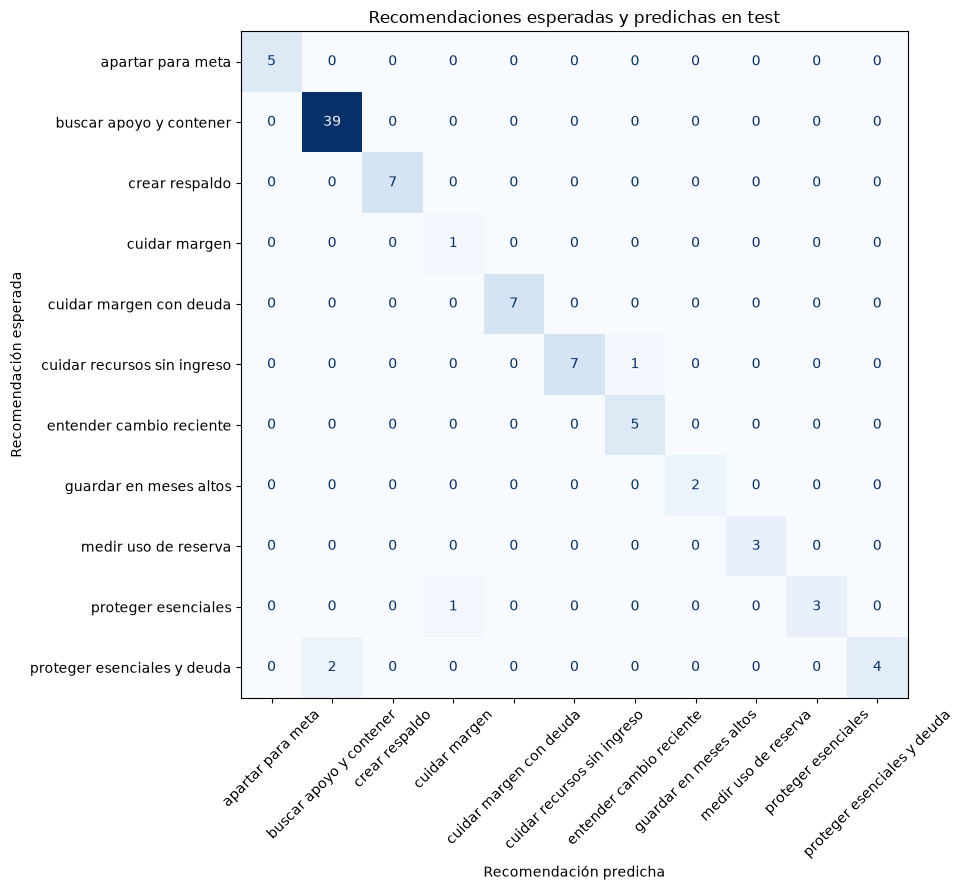

In [13]:
#Mostrar matriz de confusión
etiquetas_recomendacion = sorted(y.unique())
etiquetas_cortas = [etiqueta.replace('REC_', '').replace('_', ' ').lower() for etiqueta in etiquetas_recomendacion]
figura, eje = plt.subplots(figsize=(12, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    prediccion_test,
    labels=etiquetas_recomendacion,
    display_labels=etiquetas_cortas,
    cmap='Blues',
    colorbar=False,
    xticks_rotation=45,
    ax=eje,
)

eje.set_title('Recomendaciones esperadas y predichas en test')
eje.set_xlabel('Recomendación predicha')
eje.set_ylabel('Recomendación esperada')
figura.tight_layout()

ruta_graficas.mkdir(parents=True, exist_ok=True)
figura.savefig(ruta_graficas / '05_matriz_confusion_recomendaciones.png', dpi=180, bbox_inches='tight')
plt.show()

In [14]:
#Mostrar importancia
preparacion_final = modelo_final.named_steps['preparacion']
estimador_final = modelo_final.named_steps['modelo']
nombres_transformados = [
    nombre.split('__', 1)[-1]
    for nombre in preparacion_final.get_feature_names_out()
]

if hasattr(estimador_final, 'feature_importances_'):
    valores_importancia = estimador_final.feature_importances_
else:
    valores_importancia = np.abs(estimador_final.coef_).mean(axis=0)

importancia_variables = pd.DataFrame({
    'variable': nombres_transformados,
    'importancia': valores_importancia,
}).sort_values('importancia', ascending=False)

display(importancia_variables)

,variable,importancia
31,balance_relativo,0.076560
11,estado_ingreso_actual_sin_ingresos,0.054385
24,prob_acumulacion_estable_pct,0.050398
26,prob_equilibrio_sostenible_pct,0.049300
30,prob_variable_resiliente_pct,0.049165
25,prob_deterioro_reciente_pct,0.047856
36,cobertura_esencial_L_meses,0.047326
32,deuda_relativa,0.047298
14,tiene_deuda_si,0.044133
29,prob_uso_planificado_reserva_pct,0.043565


## 9. Catálogo y motor de guardas

In [15]:
#Construir catálogo
campos_estables_catalogo = [
    'recomendacion_id',
    'recomendacion',
    'tipo_recomendacion',
    'decision',
    'prioridad',
    'requiere_confirmacion',
    'condiciones_exclusion',
    'riesgo_si_se_aplica',
    'revision_humana',
]

controles_catalogo = datos.groupby('recomendacion_id')[campos_estables_catalogo[1:]].nunique(dropna=False)
catalogo_recomendaciones = datos[campos_estables_catalogo].drop_duplicates('recomendacion_id').set_index('recomendacion_id')

display(catalogo_recomendaciones.reset_index())
assert controles_catalogo.le(1).all().all(), 'El catálogo contiene definiciones contradictorias'

,recomendacion_id,recomendacion,tipo_recomendacion,decision,prioridad,requiere_confirmacion,condiciones_exclusion,riesgo_si_se_aplica,revision_humana
0,REC_BUSCAR_APOYO_Y_CONTENER,Los pagos y gastos superan claramente los recu...,contencion_y_revision,revisar,critica,si,no_asumir_identidad_permanente | no_eliminar_h...,Aumentar la deuda o quedarse sin recursos para...,requerida
1,REC_PROTEGER_ESENCIALES_Y_DEUDA,En este momento el dinero no alcanza con holgu...,proteccion_esencial,priorizar,alta,si,no_asumir_identidad_permanente | no_eliminar_h...,Dejar sin cobertura una necesidad básica o inc...,recomendada
2,REC_GUARDAR_EN_MESES_ALTOS,Tus ingresos cambian de un mes a otro y hasta ...,gestion_ingreso_variable,aplicar,alta,no,no_asumir_identidad_permanente | no_eliminar_h...,Usar todo el ingreso de un mes alto y quedar s...,no_requerida
3,REC_MEDIR_USO_DE_RESERVA,Estás usando parte de tu dinero disponible par...,seguimiento_reserva,vigilar,media,no,no_asumir_identidad_permanente | no_eliminar_h...,Consumir la reserva más rápido de lo previsto.,no_requerida
4,REC_CUIDAR_MARGEN_CON_DEUDA,"Tus ingresos están cubriendo tus gastos, pero ...",prevencion,mantener,media,no,no_asumir_identidad_permanente | no_eliminar_h...,Perder el margen disponible al aumentar compro...,no_requerida
5,REC_CREAR_RESPALDO,Este periodo te quedó dinero disponible. Antes...,respaldo_financiero,aplicar,media,no,no_asumir_identidad_permanente | no_eliminar_h...,Convertir todo el excedente en un compromiso f...,no_requerida
6,REC_ENTENDER_CAMBIO_RECIENTE,Este periodo cambió frente a los anteriores. R...,revision_de_cambios,revisar,alta,si,no_asumir_identidad_permanente | no_eliminar_h...,Tomar una decisión permanente por un cambio qu...,recomendada
7,REC_APARTAR_PARA_META,Este periodo te quedó dinero disponible. Puede...,ahorro_para_meta,aplicar,media,no,no_asumir_identidad_permanente | no_eliminar_h...,Apartar más dinero del que realmente queda dis...,no_requerida
8,REC_PROTEGER_ESENCIALES,En este momento el dinero no alcanza con holgu...,proteccion_esencial,priorizar,alta,no,no_asumir_identidad_permanente | no_eliminar_h...,Dejar sin cobertura una necesidad básica o inc...,no_requerida
9,REC_CUIDAR_MARGEN,"Tus ingresos están cubriendo tus gastos, pero ...",prevencion,mantener,media,no,no_asumir_identidad_permanente | no_eliminar_h...,Perder el margen disponible al aumentar compro...,no_requerida


In [16]:
#Definir motor
estados_validos = set(datos['estado_trayectoria'].unique())

def revisar_entrada_motor(entrada):
    motivos = []
    estado_calculo = entrada.get('estado_calculo_modelo')
    estado = entrada.get('estado_modelo')
    confianza = entrada.get('confianza_pct')
    cobertura = entrada.get('cobertura_esencial_L_meses')
    estado_ingreso = entrada.get('estado_ingreso_actual')
    tiene_deuda = entrada.get('tiene_deuda')
    objetivo = entrada.get('objetivo_contexto')
    objetivo_declarado = entrada.get('objetivo_declarado')

    if estado_calculo != 'calculado':
        motivos.append('estado_financiero_sin_evidencia_suficiente')
    if estado not in estados_validos:
        motivos.append('estado_fuera_del_catalogo')
    if pd.isna(confianza) or float(confianza) < UMBRAL_ESTADO * 100:
        motivos.append('confianza_del_estado_insuficiente')
    if pd.isna(cobertura):
        motivos.append('cobertura_esencial_no_calculable')
    elif float(cobertura) < 0:
        motivos.append('cobertura_esencial_fuera_de_rango')
    if estado_ingreso not in set(datos['estado_ingreso_actual'].unique()):
        motivos.append('contexto_de_ingreso_fuera_del_mvp')
    if tiene_deuda not in ['si', 'no']:
        motivos.append('estado_de_deuda_no_disponible')
    if pd.isna(objetivo) or not str(objetivo).strip():
        motivos.append('contexto_de_meta_no_disponible')
    if not isinstance(objetivo_declarado, (bool, np.bool_)):
        motivos.append('estado_de_meta_no_disponible')

    campos_financieros = [
        'balance_relativo',
        'deuda_relativa',
        'pago_deuda_relativo',
        'periodos_sin_ingreso',
        'variabilidad_ingresos_V',
    ]
    faltantes_financieros = [
        campo
        for campo in campos_financieros
        if campo not in entrada or pd.isna(entrada[campo])
    ]
    if faltantes_financieros:
        motivos.append('contexto_financiero_incompleto:' + '|'.join(faltantes_financieros))
    elif tiene_deuda == 'no' and float(entrada['deuda_relativa']) > 0:
        motivos.append('estado_de_deuda_inconsistente')

    probabilidades_faltantes = [
        columna
        for columna in columnas_probabilidad
        if columna not in entrada or pd.isna(entrada[columna])
    ]
    if probabilidades_faltantes:
        motivos.append('porcentajes_de_estado_incompletos')
    else:
        suma = sum(float(entrada[columna]) for columna in columnas_probabilidad)
        if not np.isclose(suma, 100.0, atol=1.0):
            motivos.append('porcentajes_de_estado_no_reconcilian')

    return motivos

def aplicar_guardas(recomendacion_id, entrada):
    estado = entrada['estado_modelo']
    cobertura = float(entrada['cobertura_esencial_L_meses'])
    estado_ingreso = entrada['estado_ingreso_actual']
    tiene_deuda = entrada['tiene_deuda'] == 'si'
    objetivo_declarado = bool(entrada.get('objetivo_declarado', False))
    guardas_aplicadas = []
    recomendacion_final = recomendacion_id

    if estado_ingreso == 'sin_ingresos' and estado in ['fragilidad_sostenida', 'situacion_critica', 'uso_planificado_reserva']:
        recomendacion_final = 'REC_CUIDAR_RECURSOS_SIN_INGRESO'
        guardas_aplicadas.append('recursos_protegidos_sin_ingresos')
    elif estado == 'situacion_critica':
        recomendacion_final = 'REC_BUSCAR_APOYO_Y_CONTENER'
        guardas_aplicadas.append('situacion_critica_con_revision_humana')
    elif estado == 'fragilidad_sostenida' or cobertura < COBERTURA_ESENCIAL_MINIMA_MESES:
        if tiene_deuda:
            recomendacion_final = 'REC_PROTEGER_ESENCIALES_Y_DEUDA'
            guardas_aplicadas.append('esenciales_y_deuda_protegidas')
        else:
            recomendacion_final = 'REC_PROTEGER_ESENCIALES'
            guardas_aplicadas.append('necesidades_esenciales_protegidas')
    elif estado == 'equilibrio_sostenible':
        recomendacion_final = 'REC_CUIDAR_MARGEN_CON_DEUDA' if tiene_deuda else 'REC_CUIDAR_MARGEN'
        guardas_aplicadas.append('deuda_activa_considerada' if tiene_deuda else 'margen_sin_deuda_considerado')
    elif estado == 'acumulacion_estable':
        recomendacion_final = 'REC_APARTAR_PARA_META' if objetivo_declarado else 'REC_CREAR_RESPALDO'
        guardas_aplicadas.append('meta_confirmada' if objetivo_declarado else 'meta_no_supuesta')
    elif estado == 'variable_resiliente':
        recomendacion_final = 'REC_GUARDAR_EN_MESES_ALTOS'
        guardas_aplicadas.append('variabilidad_no_tratada_como_riesgo')
    elif estado == 'uso_planificado_reserva':
        recomendacion_final = 'REC_MEDIR_USO_DE_RESERVA'
        guardas_aplicadas.append('duracion_de_reserva_considerada')
    elif estado == 'deterioro_reciente':
        recomendacion_final = 'REC_ENTENDER_CAMBIO_RECIENTE'
        guardas_aplicadas.append('cambio_reciente_requiere_revision')

    if entrada.get('hobbies_considerados') not in [None, '', 'no_declarado']:
        guardas_aplicadas.append('hobbies_no_eliminados_automaticamente')

    return recomendacion_final, guardas_aplicadas

def construir_razon(entrada, recomendacion_id, guardas_aplicadas):
    periodo_desde = entrada.get('periodo_desde', 'no_disponible')
    periodo_hasta = entrada.get('periodo_hasta', 'no_disponible')
    estado = entrada.get('estado_modelo', 'no_disponible')
    confianza = float(entrada.get('confianza_pct', 0))
    cobertura = float(entrada.get('cobertura_esencial_L_meses', 0))
    meta = entrada.get('objetivo_contexto', 'no declarado')
    return (
        f'Entre {periodo_desde} y {periodo_hasta} se observó el estado {estado} con '
        f'{confianza:.2f} % de confianza y {cobertura:.2f} meses de cobertura esencial. '
        f'La selección {recomendacion_id} considera la meta {meta} y las restricciones disponibles.'
    )

def generar_recomendacion(entrada):
    motivos = revisar_entrada_motor(entrada)

    if motivos:
        return {
            'estado_motor': 'abstencion',
            'recomendacion_id': 'no_disponible',
            'recomendacion_candidata_modelo': 'no_disponible',
            'fuente_seleccion': 'abstencion_por_evidencia',
            'recomendacion': 'No se genera una recomendación con la evidencia disponible.',
            'decision': 'abstener',
            'prioridad': 'no_aplica',
            'confianza_recomendacion_pct': np.nan,
            'confianza_candidata_modelo_pct': np.nan,
            'confianza_estado_pct': entrada.get('confianza_pct', np.nan),
            'requiere_confirmacion': 'no_aplica',
            'revision_humana': 'no_aplica',
            'razon_decision': 'Falta evidencia suficiente para seleccionar una acción segura.',
            'motivos': motivos,
            'guardas_aplicadas': [],
            'porcentajes_recomendacion': {},
        }

    fila_modelo = pd.DataFrame([entrada])[variables_modelo]
    probabilidades = modelo_final.predict_proba(fila_modelo)[0]
    posicion = int(np.argmax(probabilidades))
    confianza = float(probabilidades[posicion])
    candidata = modelo_final.classes_[posicion]
    porcentajes = {
        recomendacion: round(float(probabilidad) * 100, 2)
        for recomendacion, probabilidad in sorted(
            zip(modelo_final.classes_, probabilidades),
            key=lambda elemento: elemento[1],
            reverse=True,
        )
    }

    if confianza < UMBRAL_RECOMENDACION:
        return {
            'estado_motor': 'abstencion',
            'recomendacion_id': 'no_disponible',
            'recomendacion_candidata_modelo': candidata,
            'fuente_seleccion': 'abstencion_por_confianza',
            'recomendacion': 'Ninguna recomendación alcanzó la confianza mínima.',
            'decision': 'abstener',
            'prioridad': 'no_aplica',
            'confianza_recomendacion_pct': np.nan,
            'confianza_candidata_modelo_pct': round(confianza * 100, 2),
            'confianza_estado_pct': entrada.get('confianza_pct', np.nan),
            'requiere_confirmacion': 'no_aplica',
            'revision_humana': 'no_aplica',
            'razon_decision': 'Las alternativas del catálogo quedaron demasiado cercanas entre sí.',
            'motivos': ['confianza_de_recomendacion_insuficiente'],
            'guardas_aplicadas': [],
            'porcentajes_recomendacion': porcentajes,
        }

    recomendacion_final, guardas_aplicadas = aplicar_guardas(candidata, entrada)
    ficha = catalogo_recomendaciones.loc[recomendacion_final]
    razon = construir_razon(entrada, recomendacion_final, guardas_aplicadas)
    modificada_por_guarda = recomendacion_final != candidata
    confianza_final = np.nan if modificada_por_guarda else round(confianza * 100, 2)
    if modificada_por_guarda:
        fuente_seleccion = 'guarda_etica'
    elif guardas_aplicadas:
        fuente_seleccion = 'modelo_validado_por_guardas'
    else:
        fuente_seleccion = 'modelo_restringido'
    revision_humana = ficha['revision_humana']

    return {
        'estado_motor': 'recomendacion_disponible',
        'recomendacion_id': recomendacion_final,
        'recomendacion_candidata_modelo': candidata,
        'fuente_seleccion': fuente_seleccion,
        'recomendacion': ficha['recomendacion'],
        'tipo_recomendacion': ficha['tipo_recomendacion'],
        'decision': ficha['decision'],
        'prioridad': ficha['prioridad'],
        'confianza_recomendacion_pct': confianza_final,
        'confianza_candidata_modelo_pct': round(confianza * 100, 2),
        'confianza_estado_pct': entrada['confianza_pct'],
        'requiere_confirmacion': ficha['requiere_confirmacion'],
        'revision_humana': revision_humana,
        'razon_decision': razon,
        'aspectos_protegidos': entrada.get('aspectos_protegidos', 'necesidades_esenciales'),
        'hobbies_considerados': entrada.get('hobbies_considerados', 'no_declarado'),
        'meta_relacionada': entrada.get('objetivo_contexto', 'no declarado'),
        'condiciones_exclusion': ficha['condiciones_exclusion'],
        'riesgo_si_se_aplica': ficha['riesgo_si_se_aplica'],
        'motivos': [],
        'guardas_aplicadas': guardas_aplicadas,
        'porcentajes_recomendacion': porcentajes,
    }

## 10. Recomendaciones actuales

In [17]:
#Preparar perfiles actuales
ultimas_trayectorias = trayectorias.sort_values('fecha_corte').groupby('perfil_id').tail(1)[[
    'ventana_id',
    'perfil_id',
    'periodo_desde',
    'periodo_hasta',
    'actividad_A',
    'balance_operativo_B',
    'liquidez_final',
    'deuda_final',
    'pagos_deuda',
    'periodos_sin_ingreso',
    'variabilidad_ingresos_V',
    'cobertura_esencial_L_meses',
]]

contexto_perfiles = perfiles[[
    'perfil_id',
    'objetivo_proximo',
    'meta_declarada',
    'hobby_1',
    'hobby_2',
    'responsabilidad_declarada',
    'tipos_deuda',
]]

perfiles_motor = estados_actuales.merge(
    ultimas_trayectorias,
    on=['ventana_id', 'perfil_id', 'periodo_desde', 'periodo_hasta'],
    how='left',
    validate='one_to_one',
).merge(
    contexto_perfiles,
    on='perfil_id',
    how='left',
    validate='many_to_one',
)
perfiles_motor['balance_relativo'] = perfiles_motor['balance_operativo_B'] / perfiles_motor['actividad_A'].where(perfiles_motor['actividad_A'].gt(0))
perfiles_motor['deuda_relativa'] = perfiles_motor['deuda_final'] / perfiles_motor['actividad_A'].where(perfiles_motor['actividad_A'].gt(0))
perfiles_motor['pago_deuda_relativo'] = perfiles_motor['pagos_deuda'] / perfiles_motor['actividad_A'].where(perfiles_motor['actividad_A'].gt(0))
perfiles_motor['tiene_deuda'] = perfiles_motor['deuda_final'].gt(0).map({True: 'si', False: 'no'})
perfiles_motor['objetivo_contexto'] = perfiles_motor['objetivo_proximo'].astype('string').fillna('no declarado')

display(perfiles_motor.head(5))
assert perfiles_motor['cobertura_esencial_L_meses'].notna().all(), 'Falta cobertura esencial en perfiles actuales'

,ventana_id,perfil_id,fecha_corte,periodo_desde,periodo_hasta,estado_esperado,estado_modelo,estado_reto,estado_calculo_modelo,confianza_pct,...,meta_declarada,hobby_1,hobby_2,responsabilidad_declarada,tipos_deuda,balance_relativo,deuda_relativa,pago_deuda_relativo,tiene_deuda,objetivo_contexto
0,VEN_0164_3,PERF_0164,2026-06-30,2026-04-01,2026-06-30,situacion_critica,situacion_critica,en_riesgo,calculado,83.87,...,NaN,musica,NaN,NaN,credito,-0.099969,0.060269,0.047005,si,no declarado
1,VEN_0172_3,PERF_0172,2026-06-30,2026-04-01,2026-06-30,situacion_critica,situacion_critica,en_riesgo,calculado,99.85,...,NaN,cocina_y_reposteria,videojuegos_y_streaming,NaN,sin_deuda,-0.933754,0.000000,0.000000,no,no declarado
2,VEN_0167_3,PERF_0167,2026-06-30,2026-04-01,2026-06-30,situacion_critica,situacion_critica,en_riesgo,calculado,99.80,...,comprar_equipo_de_trabajo,turismo_y_viajes,NaN,medicamentos_de_un_familiar,credito,-0.390201,0.581700,0.038965,si,comprar equipo de trabajo
3,VEN_0196_3,PERF_0196,2026-06-30,2026-04-01,2026-06-30,situacion_critica,situacion_critica,en_riesgo,calculado,100.00,...,NaN,videojuegos_y_streaming,NaN,NaN,credito,-0.602364,0.382984,0.044628,si,no declarado
4,VEN_0184_3,PERF_0184,2026-06-30,2026-04-01,2026-06-30,equilibrio_sostenible,equilibrio_sostenible,saludable,calculado,92.02,...,ampliar_actividad_economica,musica,NaN,gastos_de_un_hijo,credito,0.056866,0.255404,0.031202,si,ampliar actividad economica


In [18]:
#Generar recomendaciones
recomendaciones_actuales = []

for indice, fila in perfiles_motor.iterrows():
    hobbies = [
        str(valor)
        for valor in [fila.get('hobby_1'), fila.get('hobby_2')]
        if pd.notna(valor) and str(valor).strip()
    ]
    protegidos = ['necesidades_esenciales']

    if pd.notna(fila.get('responsabilidad_declarada')):
        protegidos.append('responsabilidad:' + str(fila['responsabilidad_declarada']))
    if bool(fila.get('objetivo_declarado')):
        protegidos.append('meta:' + str(fila['objetivo_contexto']))
    if hobbies:
        protegidos.append('hobbies:' + '|'.join(hobbies))

    entrada = fila.to_dict()
    entrada['meta_relacionada'] = fila.get('objetivo_contexto', 'no declarado')
    entrada['hobbies_considerados'] = ' | '.join(hobbies) if hobbies else 'no_declarado'
    entrada['aspectos_protegidos'] = ' | '.join(protegidos)
    resultado = generar_recomendacion(entrada)

    registro = {
        'perfil_id': fila['perfil_id'],
        'ventana_id': fila['ventana_id'],
        'periodo_desde': fila['periodo_desde'],
        'periodo_hasta': fila['periodo_hasta'],
        'estado_trayectoria': fila['estado_modelo'],
        **resultado,
    }
    registro['motivos'] = ' | '.join(resultado.get('motivos', []))
    registro['guardas_aplicadas'] = ' | '.join(resultado.get('guardas_aplicadas', []))
    registro['porcentajes_recomendacion'] = ' | '.join(
        f'{clave}:{valor}'
        for clave, valor in resultado.get('porcentajes_recomendacion', {}).items()
    )
    recomendaciones_actuales.append(registro)

recomendaciones_actuales = pd.DataFrame(recomendaciones_actuales)
resumen_motor = recomendaciones_actuales.groupby(
    ['estado_motor', 'decision']
).size().rename('perfiles').reset_index()

display(resumen_motor)
display(recomendaciones_actuales.head(10))

,estado_motor,decision,perfiles
0,abstencion,abstener,7
1,recomendacion_disponible,aplicar,31
2,recomendacion_disponible,mantener,8
3,recomendacion_disponible,priorizar,46
4,recomendacion_disponible,revisar,105
5,recomendacion_disponible,vigilar,3


,perfil_id,ventana_id,periodo_desde,periodo_hasta,estado_trayectoria,estado_motor,recomendacion_id,recomendacion_candidata_modelo,fuente_seleccion,recomendacion,...,revision_humana,razon_decision,aspectos_protegidos,hobbies_considerados,meta_relacionada,condiciones_exclusion,riesgo_si_se_aplica,motivos,guardas_aplicadas,porcentajes_recomendacion
0,PERF_0164,VEN_0164_3,2026-04-01,2026-06-30,situacion_critica,recomendacion_disponible,REC_BUSCAR_APOYO_Y_CONTENER,REC_BUSCAR_APOYO_Y_CONTENER,modelo_validado_por_guardas,Los pagos y gastos superan claramente los recu...,...,requerida,Entre 2026-04-01 00:00:00 y 2026-06-30 00:00:0...,necesidades_esenciales | hobbies:musica,musica,no declarado,no_asumir_identidad_permanente | no_eliminar_h...,Aumentar la deuda o quedarse sin recursos para...,,situacion_critica_con_revision_humana | hobbie...,REC_BUSCAR_APOYO_Y_CONTENER:92.87 | REC_PROTEG...
1,PERF_0172,VEN_0172_3,2026-04-01,2026-06-30,situacion_critica,recomendacion_disponible,REC_CUIDAR_RECURSOS_SIN_INGRESO,REC_CUIDAR_RECURSOS_SIN_INGRESO,modelo_validado_por_guardas,"Mientras no tengas ingresos, calcula cuánto ti...",...,recomendada,Entre 2026-04-01 00:00:00 y 2026-06-30 00:00:0...,necesidades_esenciales | hobbies:cocina_y_repo...,cocina_y_reposteria | videojuegos_y_streaming,no declarado,no_asumir_identidad_permanente | no_eliminar_h...,Quedarse sin dinero para necesidades básicas a...,,recursos_protegidos_sin_ingresos | hobbies_no_...,REC_CUIDAR_RECURSOS_SIN_INGRESO:95.19 | REC_BU...
2,PERF_0167,VEN_0167_3,2026-04-01,2026-06-30,situacion_critica,recomendacion_disponible,REC_BUSCAR_APOYO_Y_CONTENER,REC_BUSCAR_APOYO_Y_CONTENER,modelo_validado_por_guardas,Los pagos y gastos superan claramente los recu...,...,requerida,Entre 2026-04-01 00:00:00 y 2026-06-30 00:00:0...,necesidades_esenciales | responsabilidad:medic...,turismo_y_viajes,comprar equipo de trabajo,no_asumir_identidad_permanente | no_eliminar_h...,Aumentar la deuda o quedarse sin recursos para...,,situacion_critica_con_revision_humana | hobbie...,REC_BUSCAR_APOYO_Y_CONTENER:98.94 | REC_CUIDAR...
3,PERF_0196,VEN_0196_3,2026-04-01,2026-06-30,situacion_critica,recomendacion_disponible,REC_BUSCAR_APOYO_Y_CONTENER,REC_BUSCAR_APOYO_Y_CONTENER,modelo_validado_por_guardas,Los pagos y gastos superan claramente los recu...,...,requerida,Entre 2026-04-01 00:00:00 y 2026-06-30 00:00:0...,necesidades_esenciales | hobbies:videojuegos_y...,videojuegos_y_streaming,no declarado,no_asumir_identidad_permanente | no_eliminar_h...,Aumentar la deuda o quedarse sin recursos para...,,situacion_critica_con_revision_humana | hobbie...,REC_BUSCAR_APOYO_Y_CONTENER:99.2 | REC_CUIDAR_...
4,PERF_0184,VEN_0184_3,2026-04-01,2026-06-30,equilibrio_sostenible,recomendacion_disponible,REC_CUIDAR_MARGEN_CON_DEUDA,REC_CUIDAR_MARGEN_CON_DEUDA,modelo_validado_por_guardas,"Tus ingresos están cubriendo tus gastos, pero ...",...,no_requerida,Entre 2026-04-01 00:00:00 y 2026-06-30 00:00:0...,necesidades_esenciales | responsabilidad:gasto...,musica,ampliar actividad economica,no_asumir_identidad_permanente | no_eliminar_h...,Perder el margen disponible al aumentar compro...,,deuda_activa_considerada | hobbies_no_eliminad...,REC_CUIDAR_MARGEN_CON_DEUDA:91.36 | REC_CUIDAR...
5,PERF_0160,VEN_0160_3,2026-04-01,2026-06-30,situacion_critica,recomendacion_disponible,REC_BUSCAR_APOYO_Y_CONTENER,REC_BUSCAR_APOYO_Y_CONTENER,modelo_validado_por_guardas,Los pagos y gastos superan claramente los recu...,...,requerida,Entre 2026-04-01 00:00:00 y 2026-06-30 00:00:0...,necesidades_esenciales | responsabilidad:aport...,ciclismo | turismo_y_viajes,mejorar vivienda,no_asumir_identidad_permanente | no_eliminar_h...,Aumentar la deuda o quedarse sin recursos para...,,situacion_critica_con_revision_humana | hobbie...,REC_BUSCAR_APOYO_Y_CONTENER:98.58 | REC_CUIDAR...
6,PERF_0189,VEN_0189_3,2026-04-01,2026-06-30,situacion_critica,recomendacion_disponible,REC_BUSCAR_APOYO_Y_CONTENER,REC_BUSCAR_APOYO_Y_CONTENER,modelo_validado_por_guardas,Los pago

## 11. Gráfica

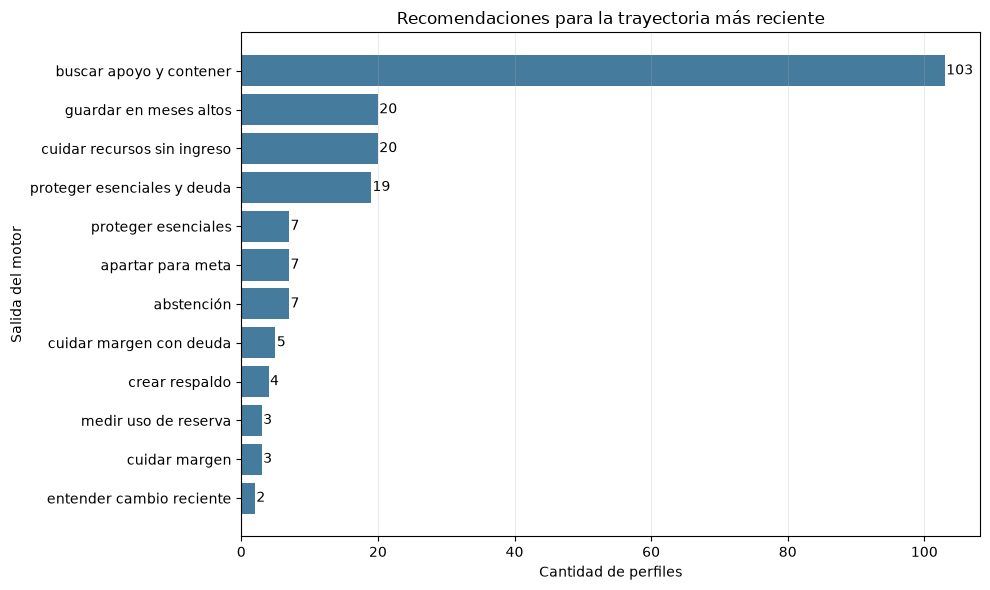

In [19]:
#Graficar recomendaciones
distribucion_recomendaciones = recomendaciones_actuales['recomendacion_id'].value_counts().sort_values()
etiquetas = [
    'abstención' if etiqueta == 'no_disponible' else etiqueta.replace('REC_', '').replace('_', ' ').lower()
    for etiqueta in distribucion_recomendaciones.index
]

figura, eje = plt.subplots(figsize=(10, 6))
eje.barh(etiquetas, distribucion_recomendaciones.values, color='#457B9D')
eje.set_title('Recomendaciones para la trayectoria más reciente')
eje.set_xlabel('Cantidad de perfiles')
eje.set_ylabel('Salida del motor')
eje.grid(axis='x', alpha=0.25)

for posicion, valor in enumerate(distribucion_recomendaciones.values):
    eje.text(valor + 0.2, posicion, str(int(valor)), va='center')

figura.tight_layout()
figura.savefig(ruta_graficas / '05_distribucion_recomendaciones.png', dpi=180, bbox_inches='tight')
plt.show()

## 12. Serialización y exportación

In [20]:
#Guardar artefactos
ruta_modelo.parent.mkdir(parents=True, exist_ok=True)
ruta_resultados.mkdir(parents=True, exist_ok=True)

artefacto = {
    'version_modelo': VERSION_MODELO,
    'modelo': modelo_final,
    'modelo_seleccionado': nombre_modelo_final,
    'variables_modelo': variables_modelo,
    'variables_categoricas': variables_categoricas,
    'variables_numericas': variables_numericas,
    'columnas_probabilidad': columnas_probabilidad,
    'catalogo_recomendaciones': catalogo_recomendaciones.reset_index().to_dict(orient='records'),
    'guardas_eticas': guardas_eticas.to_dict(orient='records'),
    'umbral_estado': UMBRAL_ESTADO,
    'umbral_recomendacion': UMBRAL_RECOMENDACION,
    'cobertura_esencial_minima_meses': COBERTURA_ESENCIAL_MINIMA_MESES,
    'metricas_validation': metricas_validation.to_dict(orient='records'),
    'metricas_test': metricas_test.to_dict(orient='records'),
    'version_modelo_estados': artefacto_estados['version_modelo'],
    'version_catalogo': str(decisiones['version_catalogo'].iloc[0]),
    'version_esquema_decisiones': str(decisiones['version_esquema'].iloc[0]),
    'definicion_recurrencia': 'evidencia temporal descriptiva que no decide por sí sola una recomendación',
    'limitacion': 'el catálogo está cerrado a once recomendaciones y debe abstenerse fuera de sus condiciones conocidas',
    'principio_etico': 'las guardas tienen prioridad sobre la probabilidad del modelo',
    'atributos_no_utilizados': ['ocupacion', 'ingreso_mensual', 'hobbies', 'habito_ahorro', 'recurrencias_observadas', 'recurrencias_fijas_observadas', 'recurrencias_variables_observadas'],
}

joblib.dump(artefacto, ruta_modelo)

ruta_recomendaciones = ruta_resultados / '05_recomendaciones.csv'
ruta_metricas = ruta_resultados / '05_metricas_modelo.csv'
recomendaciones_actuales.to_csv(ruta_recomendaciones, index=False)
pd.concat([
    metricas_validation.assign(particion='validation'),
    metricas_test.assign(particion='test'),
], ignore_index=True).to_csv(ruta_metricas, index=False)

archivos_generados = pd.DataFrame([
    {'artefacto': 'motor serializado', 'ruta': str(ruta_modelo), 'filas': np.nan},
    {'artefacto': 'recomendaciones actuales', 'ruta': str(ruta_recomendaciones), 'filas': len(recomendaciones_actuales)},
    {'artefacto': 'métricas', 'ruta': str(ruta_metricas), 'filas': len(metricas_validation) + len(metricas_test)},
])

display(archivos_generados)

,artefacto,ruta,filas
0,motor serializado,../Modelos/05_motor_recomendaciones.joblib,NaN
1,recomendaciones actuales,../Resultados/05_recomendaciones.csv,200.0
2,métricas,../Resultados/05_metricas_modelo.csv,3.0


## 13. Pruebas manuales

In [21]:
#Probar trayectoria estable
test_estable_meta = {
    'estado_modelo': 'acumulacion_estable',
    'estado_calculo_modelo': 'calculado',
    'confianza_pct': 78.04,
    'estado_ingreso_actual': 'variable',
    'objetivo_declarado': True,
    'tiene_deuda': 'si',
    'objetivo_contexto': 'mejorar vivienda',
    'balance_relativo': 0.2043,
    'deuda_relativa': 1.2925,
    'pago_deuda_relativo': 0.0332,
    'periodos_sin_ingreso': 0,
    'variabilidad_ingresos_V': 0.0,
    'cobertura_esencial_L_meses': 8.7331,
    'periodo_desde': '2026-04-01',
    'periodo_hasta': '2026-06-30',
    'meta_relacionada': 'mejorar vivienda',
    'hobbies_considerados': 'ciclismo | fotografia_y_video',
    'aspectos_protegidos': 'necesidades_esenciales | meta:crear_fondo_emergencia | hobbies:ciclismo|fotografia_y_video',
    'prob_acumulacion_estable_pct': 78.04,
    'prob_deterioro_reciente_pct': 0.0,
    'prob_equilibrio_sostenible_pct': 17.61,
    'prob_fragilidad_sostenida_pct': 0.05,
    'prob_situacion_critica_pct': 0.0,
    'prob_uso_planificado_reserva_pct': 2.85,
    'prob_variable_resiliente_pct': 1.45,
}

resultado_estable = generar_recomendacion(test_estable_meta)
display(pd.DataFrame([{
    'caso': 'estable_con_meta',
    'estado_motor': resultado_estable['estado_motor'],
    'recomendacion_id': resultado_estable['recomendacion_id'],
    'decision': resultado_estable['decision'],
    'confianza_pct': resultado_estable['confianza_recomendacion_pct'],
    'guardas': resultado_estable['guardas_aplicadas'],
}]))

display(pd.DataFrame([resultado_estable['porcentajes_recomendacion']]))
assert resultado_estable['recomendacion_id'] == 'REC_APARTAR_PARA_META'

,caso,estado_motor,recomendacion_id,decision,confianza_pct,guardas
0,estable_con_meta,recomendacion_disponible,REC_APARTAR_PARA_META,aplicar,66.81,"[meta_confirmada, hobbies_no_eliminados_automa..."


,REC_APARTAR_PARA_META,REC_CREAR_RESPALDO,REC_CUIDAR_MARGEN_CON_DEUDA,REC_GUARDAR_EN_MESES_ALTOS,REC_MEDIR_USO_DE_RESERVA,REC_BUSCAR_APOYO_Y_CONTENER,REC_CUIDAR_MARGEN,REC_CUIDAR_RECURSOS_SIN_INGRESO,REC_ENTENDER_CAMBIO_RECIENTE,REC_PROTEGER_ESENCIALES,REC_PROTEGER_ESENCIALES_Y_DEUDA
0,66.81,32.55,0.41,0.22,0.02,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
#Probar fragilidad con deuda
test_cobertura_reducida = {
    'estado_modelo': 'fragilidad_sostenida',
    'estado_calculo_modelo': 'calculado',
    'confianza_pct': 87.33,
    'estado_ingreso_actual': 'apoyo',
    'objetivo_declarado': False,
    'tiene_deuda': 'si',
    'objetivo_contexto': 'no declarado',
    'balance_relativo': -0.5797,
    'deuda_relativa': 0.1407,
    'pago_deuda_relativo': 0.0154,
    'periodos_sin_ingreso': 2,
    'variabilidad_ingresos_V': 0.0,
    'cobertura_esencial_L_meses': 1.2278,
    'periodo_desde': '2026-04-01',
    'periodo_hasta': '2026-06-30',
    'meta_relacionada': 'no declarado',
    'hobbies_considerados': 'musica | impresion_3d',
    'aspectos_protegidos': 'vivienda | alimentacion | salud | hobbies:musica|impresion_3d',
    'prob_acumulacion_estable_pct': 0.0,
    'prob_deterioro_reciente_pct': 2.67,
    'prob_equilibrio_sostenible_pct': 0.0,
    'prob_fragilidad_sostenida_pct': 87.33,
    'prob_situacion_critica_pct': 4.73,
    'prob_uso_planificado_reserva_pct': 5.15,
    'prob_variable_resiliente_pct': 0.13,
}

resultado_cobertura = generar_recomendacion(test_cobertura_reducida)
display(pd.DataFrame([{
    'caso': 'fragilidad_con_deuda_activa',
    'estado_motor': resultado_cobertura['estado_motor'],
    'recomendacion_id': resultado_cobertura['recomendacion_id'],
    'decision': resultado_cobertura['decision'],
    'revision_humana': resultado_cobertura['revision_humana'],
    'guardas': resultado_cobertura['guardas_aplicadas'],
}]))

display(pd.DataFrame([resultado_cobertura['porcentajes_recomendacion']]))
assert resultado_cobertura['recomendacion_id'] == 'REC_PROTEGER_ESENCIALES_Y_DEUDA'
assert 'esenciales_y_deuda_protegidas' in resultado_cobertura['guardas_aplicadas']

,caso,estado_motor,recomendacion_id,decision,revision_humana,guardas
0,fragilidad_con_deuda_activa,recomendacion_disponible,REC_PROTEGER_ESENCIALES_Y_DEUDA,priorizar,recomendada,"[esenciales_y_deuda_protegidas, hobbies_no_eli..."


,REC_PROTEGER_ESENCIALES_Y_DEUDA,REC_PROTEGER_ESENCIALES,REC_CUIDAR_RECURSOS_SIN_INGRESO,REC_ENTENDER_CAMBIO_RECIENTE,REC_MEDIR_USO_DE_RESERVA,REC_GUARDAR_EN_MESES_ALTOS,REC_BUSCAR_APOYO_Y_CONTENER,REC_APARTAR_PARA_META,REC_CREAR_RESPALDO,REC_CUIDAR_MARGEN,REC_CUIDAR_MARGEN_CON_DEUDA
0,94.14,2.93,1.76,0.66,0.22,0.13,0.13,0.05,0.0,0.0,0.0


In [23]:
#Probar evidencia insuficiente
test_evidencia_insuficiente = {
    'estado_modelo': 'no_disponible',
    'estado_calculo_modelo': 'evidencia_insuficiente',
    'confianza_pct': np.nan,
    'estado_ingreso_actual': 'variable',
    'objetivo_declarado': True,
    'tiene_deuda': 'no',
    'objetivo_contexto': 'crear fondo emergencia',
    'cobertura_esencial_L_meses': np.nan,
    'periodo_desde': '2026-06-30',
    'periodo_hasta': '2026-06-30',
    'meta_relacionada': 'crear_fondo_emergencia',
    'hobbies_considerados': 'ciclismo',
}

resultado_insuficiente = generar_recomendacion(test_evidencia_insuficiente)

display(pd.DataFrame([{
    'caso': 'evidencia_insuficiente',
    'estado_motor': resultado_insuficiente['estado_motor'],
    'recomendacion_id': resultado_insuficiente['recomendacion_id'],
    'decision': resultado_insuficiente['decision'],
    'motivos': resultado_insuficiente['motivos'],
    'porcentajes_recomendacion': resultado_insuficiente['porcentajes_recomendacion'],
}]))

assert resultado_insuficiente['estado_motor'] == 'abstencion'
assert resultado_insuficiente['recomendacion_id'] == 'no_disponible'
assert resultado_insuficiente['porcentajes_recomendacion'] == {}

,caso,estado_motor,recomendacion_id,decision,motivos,porcentajes_recomendacion
0,evidencia_insuficiente,abstencion,no_disponible,abstener,"[estado_financiero_sin_evidencia_suficiente, e...",{}
